In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from models import pinn_top_opt 
from utils import fem_torch

In [3]:
print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


Epoch 1/10000 | Loss: 204.5189 | Compliance: 134.5037 | Mass: 0.4700 | Mass Constraint: 0.0700


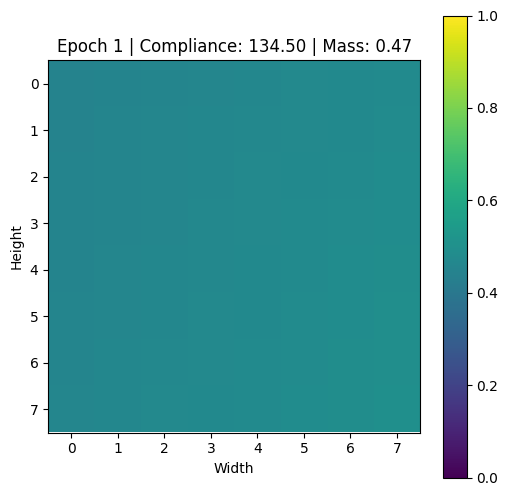

Epoch 1000/10000 | Loss: 57.8754 | Compliance: 57.8754 | Mass: 0.3982 | Mass Constraint: 0.0000


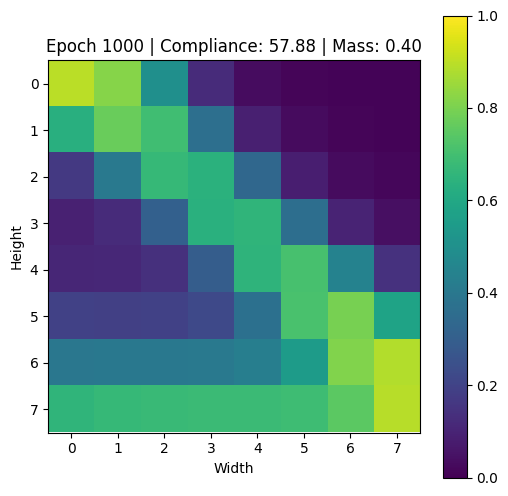

Epoch 2000/10000 | Loss: 35.0578 | Compliance: 35.0578 | Mass: 0.3969 | Mass Constraint: 0.0000


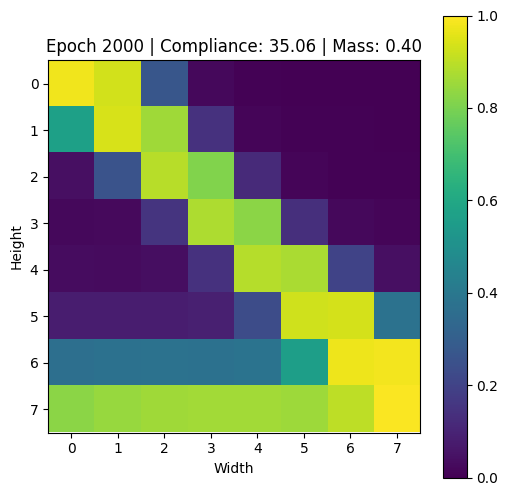

Epoch 3000/10000 | Loss: 29.8800 | Compliance: 29.8800 | Mass: 0.3960 | Mass Constraint: 0.0000


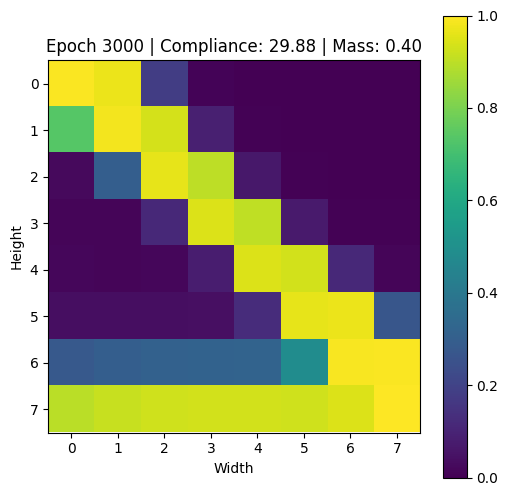

Epoch 4000/10000 | Loss: 27.8129 | Compliance: 27.8129 | Mass: 0.3945 | Mass Constraint: 0.0000


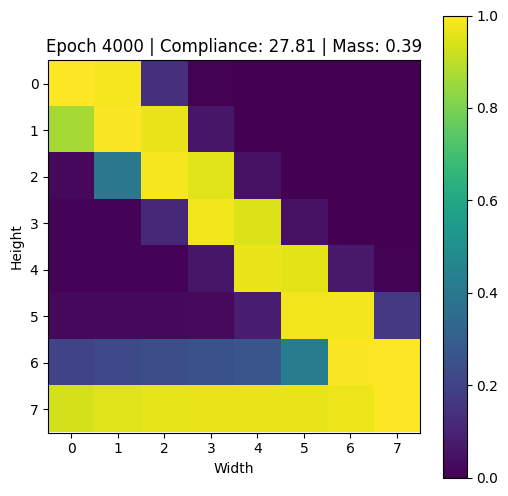

Epoch 5000/10000 | Loss: 26.6229 | Compliance: 26.6229 | Mass: 0.3993 | Mass Constraint: 0.0000


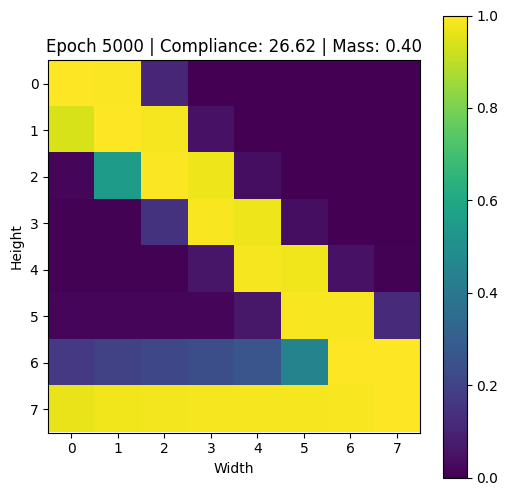

Epoch 6000/10000 | Loss: 26.4430 | Compliance: 26.4430 | Mass: 0.3893 | Mass Constraint: 0.0000


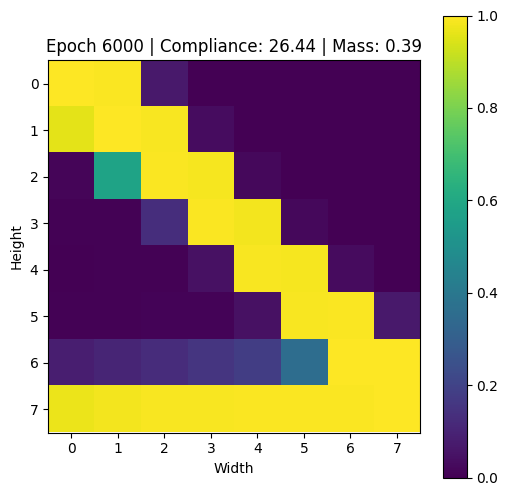

Epoch 7000/10000 | Loss: 25.9347 | Compliance: 25.9347 | Mass: 0.3976 | Mass Constraint: 0.0000


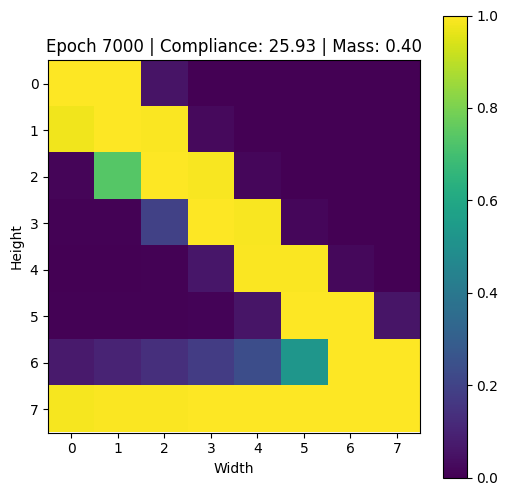

Epoch 8000/10000 | Loss: 26.1188 | Compliance: 26.1188 | Mass: 0.3827 | Mass Constraint: 0.0000


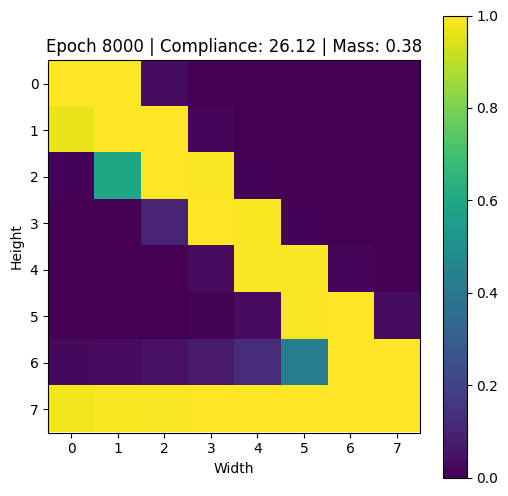

Epoch 9000/10000 | Loss: 25.7950 | Compliance: 25.7950 | Mass: 0.3888 | Mass Constraint: 0.0000


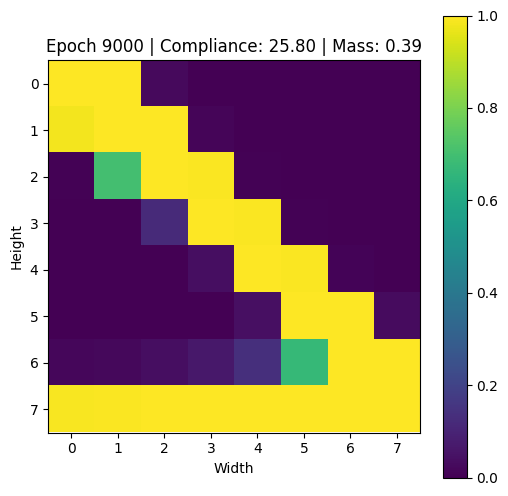

Epoch 10000/10000 | Loss: 25.6255 | Compliance: 25.6255 | Mass: 0.3928 | Mass Constraint: 0.0000


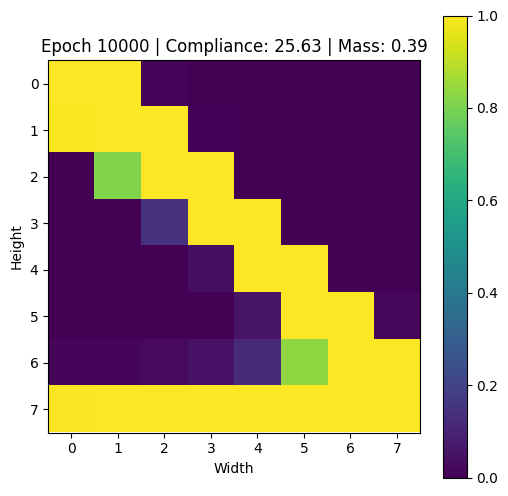

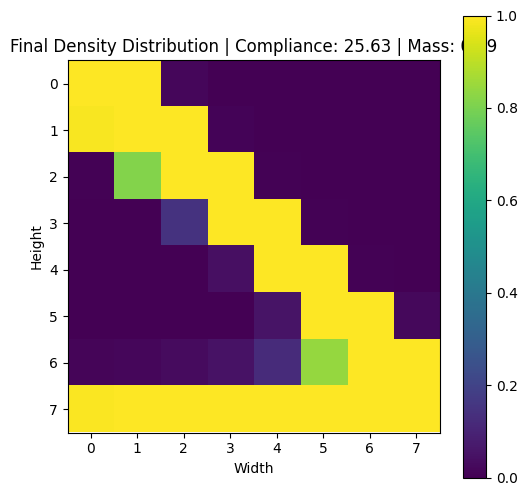

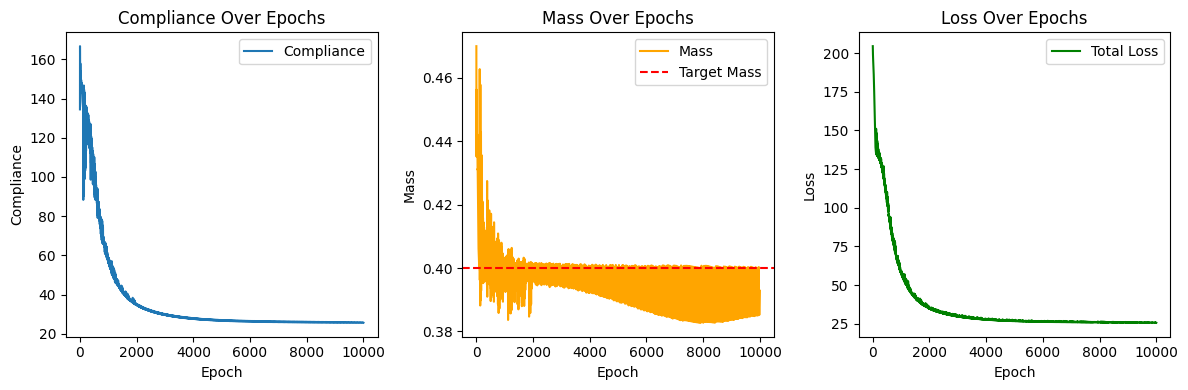

Final density distribution saved as 'final_density.npy'.
Trained model saved as 'density_pinn_trained.pth'.


In [ ]:



def generate_coordinates(nelx, nely):

    x = torch.linspace(0, 1, nelx)
    y = torch.linspace(0, 1, nely)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    coords = torch.stack([X.flatten(), Y.flatten()], dim=1)
    return coords

def main():
    
    width, height = 8, 8
    density_initial = 0.4
    
    coords = generate_coordinates(width, height)
    
    normals, forces, density = fem_torch.mbb_beam_1(width, height, density_initial)
    
    args = fem_torch.get_args(normals, forces, density)
    args['nely'] = height
    args['nelx'] = width
    
    args['mask'] = torch.ones((args['nely'], args['nelx']), dtype=torch.float32, device='cpu')
    

    model = pinn_top_opt.DensityPINN(width=width, height=height, hidden_dim=64)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    coords = coords.to(device)
    args['mask'] = args['mask'].to(device)
    

    
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = int(1e4)
    print_every = 1000
    

    compliance_history = []
    mass_history = []
    loss_history = []
    
    for epoch in range(1, num_epochs + 1):
        optimizer.zero_grad()
        
        density_pred = model(coords) 
        
        compliance, mass = fem_torch.compliance_and_constraint(density_pred, args)
        

        lambda_mass = 1000.0
        mass_constraint = torch.relu(mass - args['density'])
        loss = compliance + lambda_mass * mass_constraint
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Store history
        compliance_history.append(compliance.item())
        mass_history.append(mass.item())
        loss_history.append(loss.item())
        
        # Logging
        if epoch % print_every == 0 or epoch == 1:
            print(f'Epoch {epoch}/{num_epochs} | Loss: {loss.item():.4f} | Compliance: {compliance.item():.4f} | Mass: {mass.item():.4f} | Mass Constraint: {mass_constraint.item():.4f}')
            
            # Optional: Visualize intermediate density distributions
            density_matrix = density_pred.detach().cpu().numpy().reshape(height, width)
            plt.figure(figsize=(6,6))
            plt.imshow(density_matrix, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
            plt.colorbar()
            plt.title(f"Epoch {epoch} | Compliance: {compliance.item():.2f} | Mass: {mass.item():.2f}")
            plt.xlabel("Width")
            plt.ylabel("Height")
            plt.show()
    
    # -------------------------------
    # 5. Post-Training Visualization
    # -------------------------------
    
    # Final density distribution
    final_density = model(coords).detach().cpu().numpy().reshape(height, width)
    
    # Plot final density distribution
    plt.figure(figsize=(6,6))
    plt.imshow(final_density, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar()
    plt.title(f"Final Density Distribution | Compliance: {compliance.item():.2f} | Mass: {mass.item():.2f}")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()
    
    # Plot training history
    epochs = np.arange(1, num_epochs + 1)
    
    plt.figure(figsize=(12, 4))
    
    # Compliance over epochs
    plt.subplot(1, 3, 1)
    plt.plot(epochs, compliance_history, label='Compliance')
    plt.xlabel('Epoch')
    plt.ylabel('Compliance')
    plt.title('Compliance Over Epochs')
    plt.legend()
    
    # Mass over epochs
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mass_history, label='Mass', color='orange')
    plt.axhline(y=args['density'], color='r', linestyle='--', label='Target Mass')
    plt.xlabel('Epoch')
    plt.ylabel('Mass')
    plt.title('Mass Over Epochs')
    plt.legend()
    
    # Loss over epochs
    plt.subplot(1, 3, 3)
    plt.plot(epochs, loss_history, label='Total Loss', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # -------------------------------
    # 6. Save the Final Density Distribution (Optional)
    # -------------------------------
    
    # Save the final density as a NumPy array
    np.save('final_density.npy', final_density)
    print("Final density distribution saved as 'final_density.npy'.")

    model_save_path = 'density_pinn_trained.pth'
    torch.save(model.state_dict(), model_save_path)
    print(f"Trained model saved as '{model_save_path}'.")

if __name__ == "__main__":
    main()


Using device: cuda
Trained model loaded from 'density_pinn_trained.pth'.
Compliance: 3659672320.0000
Mass: 0.3933


/tmp/ipykernel_31974/2215804553.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path, map_location=device))


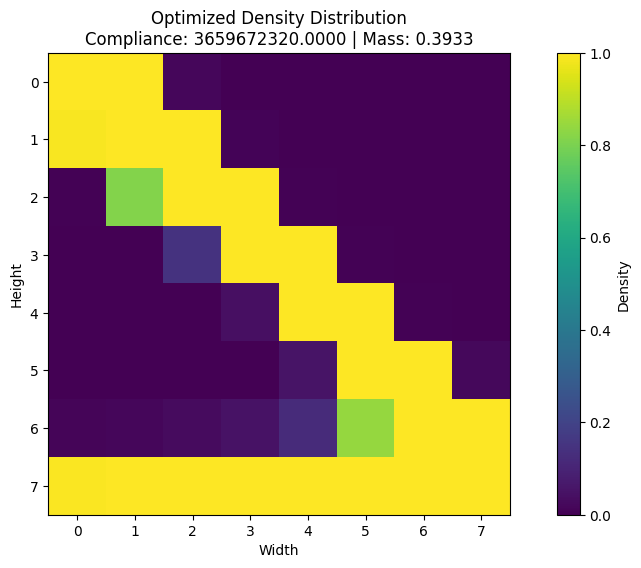

Optimized density distribution saved as 'optimized_density.npy'.


In [ ]:
def generate_coordinates(nelx, nely, device):

    x = torch.linspace(0, 1, nelx, device=device)
    y = torch.linspace(0, 1, nely, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    coords = torch.stack([X.flatten(), Y.flatten()], dim=1)
    return coords


def main():
    # -------------------------------
    # 1. Set Up the Problem
    # -------------------------------
    
    # Grid parameters (must match those used during training)
    width, height = 8, 8  # Number of elements in x and y directions
    density_initial = 0.4    # Initial density
    
    # Define device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Generate coordinates
    coords = generate_coordinates(width, height, device)
    
    # Define beam configuration
    normals, forces, density = fem_torch.mbb_beam_4(width, height, density_initial)
    
    # Extract FEM parameters
    args = fem_torch.get_args(normals, forces, density)
    args['nely'] = height
    args['nelx'] = width
    
    # Define a uniform mask (all ones) or customize as needed
    args['mask'] = torch.ones((args['nely'], args['nelx']), dtype=torch.float32, device=device)
    
    # Move other tensor entries to device
    args['forces'] = args['forces'].to(device)
    args['fixdofs'] = args['fixdofs'].to(device)
    args['freedofs'] = args['freedofs'].to(device)
    
    # -------------------------------
    # 2. Initialize the PINN
    # -------------------------------
    
    # Initialize the DensityPINN
    model = pinn_top_opt.DensityPINN(width=width, height=height, hidden_dim=64)
    
    # Move model to appropriate device (CPU or GPU)
    model.to(device)
    

    
    model_save_path = 'density_pinn_trained.pth'
    
    # Load the model's state_dict
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()  # Set model to evaluation mode
    print(f"Trained model loaded from '{model_save_path}'.")
    

    
    with torch.no_grad():
        density_pred = model(coords)  
        
        compliance, mass = fem_torch.compliance_and_constraint(density_pred, args)
        
        optimized_density = density_pred.cpu().numpy().reshape(height, width)
        
        print(f"Compliance: {compliance.item():.4f}")
        print(f"Mass: {mass.item():.4f}")
    

    plt.figure(figsize=(12, 6))
    plt.imshow(optimized_density, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Density')
    plt.title(f"Optimized Density Distribution\nCompliance: {compliance.item():.4f} | Mass: {mass.item():.4f}")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()
    
    np.save('optimized_density.npy', optimized_density)
    print("Optimized density distribution saved as 'optimized_density.npy'.")
    


if __name__ == "__main__":
    main()